# Paso 1. Importar librerías

In [2]:
# Revisar coincidencias difusas entre cadenas de texto
#!pip install geopandas plotly shapely folium fuzzywuzzy python-Levenshtein
#!pip install pandas gradio matplotlib openai tqdm

# Util cuando ciertas advertencias no son críticas y o queremos que aparezcan en la salida
import warnings
warnings.filterwarnings('ignore')

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

# Datos geoespaciales
import geopandas as gpd
from shapely.geometry import shape
import folium

# Utilidades y manejo de archivos
import glob
import os

# Autorización para que GoogleColab acceda a Drive
from google.colab import drive
drive.mount('/content/drive')

# Opciones de visualización de pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Establecer paleta de colores global usando 'viridis'
sns.set_palette("viridis")

# Para poder extraer un color base de esa paleta:
base_color = sns.color_palette("viridis")[0]


Mounted at /content/drive


# 2 Función Análisis Exploratorio de Datos

In [3]:
# Definimos una función llamada 'exploracion_inicial' que puede llegar a recibir dos parametros
# 1- df         = DataFrame
# 2- tipo=None  = un argumento opcional para indicar si queremos una exploracion simple o completa

def exploracion_inicial(df, tipo=None):
    print("¿Cuántas filas y columnas hay en el conjunto de datos?")
    num_filas, num_columnas = df.shape
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    if tipo == 'simple':
        print ("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display (df.head(2))

# Explicación de la función

# num_filas, num_columnas = df.shape
# df.shape                  = Me devuelve una tupla que contiene dos elementos:  Filas y Columnas
# num_filas, num_columnas   = como devuelve dos elementos podemos crear dos variables con la infomración que me esta devolviendo
#                             esta funcion  -> num_filas y num_columnas

# print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
# f""           me permite incluir variables dentro de una cadena de texto
# \t            me añade un tabulador al inicio del texto
# {num_filas:,} la coma indica que, cuando haya números grandes debe mostrar la coma como separador de miles

#if tipo == 'simple':
#     display (df.head(2))
# si recibe el valor 'simple' me mostrara (display) de una forma visualmente más atractiva (que utilizando la función 'print')
# las dos primeras filas



    else:
        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n=5))

        print("¿Cuáles son las columnas del conjunto de datos?")
        print("\n".join(f"\t- {col}" for col in df.columns))

        # "\n"                   une las cadenas generadas con saldos de linea
        # \t-                    añade un tabulador (\t) y un guion (-)
        # join(f"\t- {col}" for col in df.columns itero por todas las columnas del df


        print("¿Cuál es el tipo de datos de cada columna?")
        display(df.dtypes)

        print("¿Cuántas columnas hay de cada tipo de datos?")
        display(df.dtypes.value_counts())

        print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
        df.info()

        print("¿Cuántos valores únicos tiene cada columna?")
        display(df.nunique())

        print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
        display(df.describe(include='all').fillna(''))

        print("¿Hay valores nulos en el conjunto de datos?")
        display(df.isnull().sum())

        print("¿Cuál es la proporción de valores nulos en cada columna?")
        display((df.isnull().sum() / len(df) * 100).round(2))

    print('#' * 90)

# 3 Carga de datos

In [4]:
# payments Dataset
df_payments = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/00. Datos/olist_order_payments_dataset.csv")

# 4 Payments Dataset

In [5]:
exploracion_inicial(df_payments,'')

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 103,886 filas y 5 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


¿Cuáles son las últimas cinco filas del conjunto de datos?


,order_id,payment_sequential,payment_type,payment_installments,payment_value
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54
103885,28bbae6599b09d39ca406b747b6632b1,1,boleto,1,191.58


¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

¿Hay valores nulos en el conjunto de datos?


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


¿Cuál es la proporción de valores nulos en cada columna?


,0
order_id,0.0
payment_sequential,0.0
payment_type,0.0
payment_installments,0.0
payment_value,0.0


##########################################################################################


## 4.1 Conclusiones exploración inicial

Contiene información financiera sobre cómo se realizaron los pagos de los pedidos

Nos sirve para entender:
* el comportamiento de pago de los clientes,
* los métodos más usados,
* y cómo se fragmentan los pagos.

Consta de los siguientes campos:

| Campo             |      descripcion   |     tipo de datos   | Acción
|-------------------|--------------------|---------------------|-------
|**order_id** | id_pedido |  object             
| **payment_sequential** | orden del pago dentro del pedido |  int64  |  
| **payment_type** | Método de pago uilizado. tc, voucher, etc |  object             
| **payment_installments** | cuotas_pago |  int64              
| **payment_value**| monto_pago |  float64|

*   No existen valores nulos.

## 4.2 Exportación df_payments
No se detectaron acciones por realizar. Se exporta el archivo.



In [6]:
df_payments.to_csv('/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/01. Archivos CSV Limpios/df_payments_clean.csv', index=False)

# 5 Análisis descriptivo básico

## 5.1 Métodos de pagos más utilizados

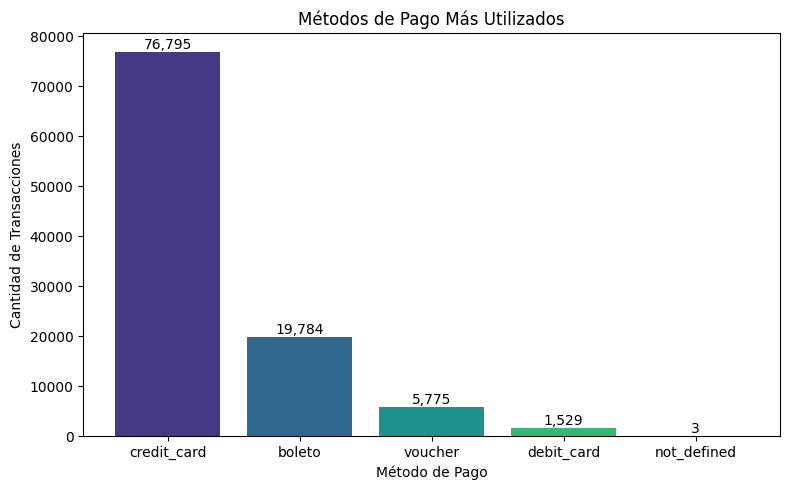

In [7]:
# Contar métodos de pago
metodos_pago = (
    df_payments['payment_type']
    .value_counts()
    .reset_index()
)
metodos_pago.columns = ['metodo_pago', 'cantidad']  # Renombrar columnas correctamente

# Colores viridis
viridis_colors = sns.color_palette("viridis", n_colors=len(metodos_pago))

# Graficar
plt.figure(figsize=(8, 5))
bars = plt.bar(metodos_pago['metodo_pago'], metodos_pago['cantidad'], color=viridis_colors)
plt.title('Métodos de Pago Más Utilizados')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de Transacciones')

# Añadir etiquetas
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()



## 5.2 Resumen de pagos

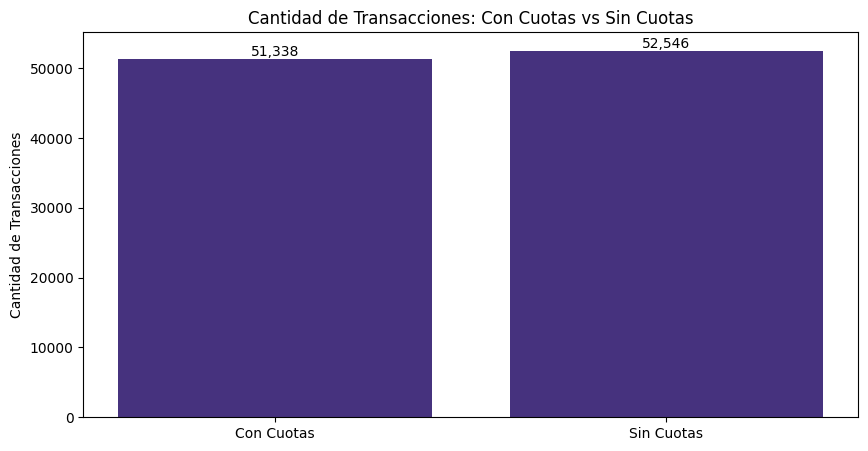

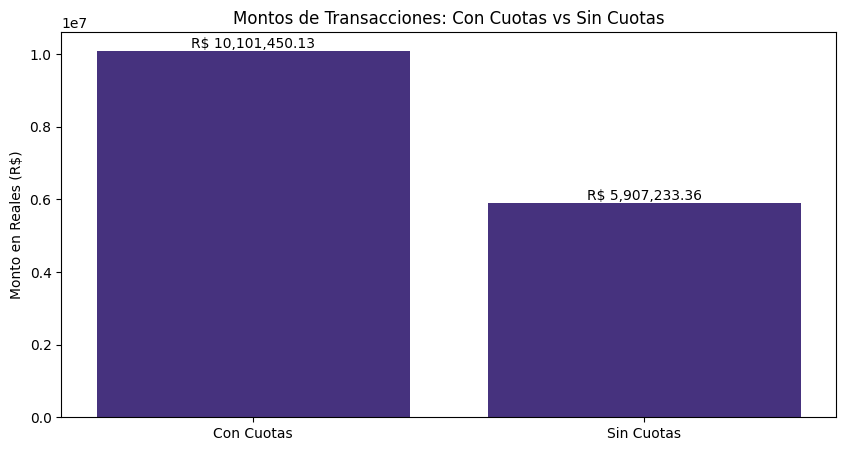

In [9]:
# Calcular la cantidad total de transacciones
total_transacciones = len(df_payments)

# Calcular el monto total de todas las transacciones
monto_total = df_payments['payment_value'].sum()

# Clasificar si las transacciones se pagan en cuotas o no
cuotas = df_payments['payment_installments'] > 1
sin_cuotas = df_payments['payment_installments'] == 1

# Cantidad de transacciones en cuotas y sin cuotas
transacciones_con_cuotas = cuotas.sum()
transacciones_sin_cuotas = sin_cuotas.sum()

# Montos totales en cuotas y sin cuotas
monto_con_cuotas = df_payments.loc[cuotas, 'payment_value'].sum()
monto_sin_cuotas = df_payments.loc[sin_cuotas, 'payment_value'].sum()

# Datos para el gráfico
labels = ['Con Cuotas', 'Sin Cuotas']
transacciones = [transacciones_con_cuotas, transacciones_sin_cuotas]
montos = [monto_con_cuotas, monto_sin_cuotas]

# Gráfico de barras para cantidad de transacciones con anotaciones
plt.figure(figsize=(10, 5))
bars = plt.bar(labels, transacciones)
plt.title('Cantidad de Transacciones: Con Cuotas vs Sin Cuotas')
plt.ylabel('Cantidad de Transacciones')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,}', va='bottom', ha='center')
plt.show()

# Gráfico de barras para montos con anotaciones
plt.figure(figsize=(10, 5))
bars = plt.bar(labels, montos)
plt.title('Montos de Transacciones: Con Cuotas vs Sin Cuotas')
plt.ylabel('Monto en Reales (R$)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'R$ {yval:,.2f}', va='bottom', ha='center')
plt.show()


Pagos sin cuotas - métodos de pago

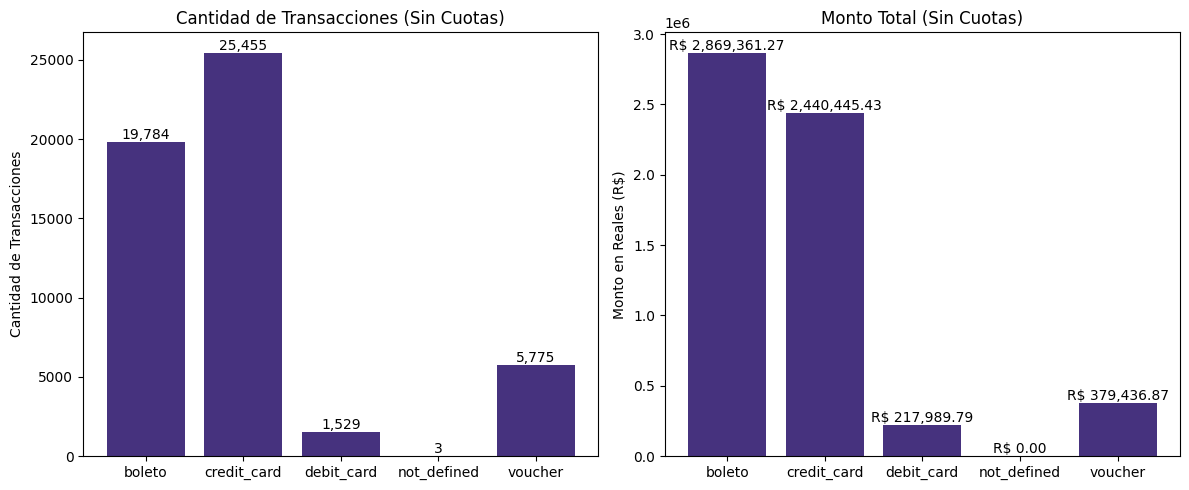

In [ ]:
# Filtrar las transacciones que se pagaron sin cuotas
pagos_sin_cuotas = df_payments[df_payments['payment_installments'] == 1]

# Agrupar y calcular transacciones y montos por tipo de pago solo para pagos sin cuotas
resumen_sin_cuotas = pagos_sin_cuotas.groupby('payment_type').agg(
    cantidad_transacciones=('payment_value', 'count'),
    monto_total=('payment_value', 'sum')
).reset_index()

# Unir los dos gráficos en una sola figura con subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Primer gráfico: cantidad de transacciones
bars1 = axes[0].bar(resumen_sin_cuotas['payment_type'], resumen_sin_cuotas['cantidad_transacciones'])
axes[0].set_title('Cantidad de Transacciones (Sin Cuotas)')
axes[0].set_ylabel('Cantidad de Transacciones')
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,}', va='bottom', ha='center')

# Segundo gráfico: monto total
bars2 = axes[1].bar(resumen_sin_cuotas['payment_type'], resumen_sin_cuotas['monto_total'])
axes[1].set_title('Monto Total (Sin Cuotas)')
axes[1].set_ylabel('Monto en Reales (R$)')
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'R$ {yval:,.2f}', va='bottom', ha='center')

plt.tight_layout()
plt.show()


# 6 Payments Dataset whith qty

Para facilitar la unión de tablas se trabaja en una nueva tabla que contenga la siguiente información:


| Campo             |      descripcion   |     tipo de datos   | Acción
|-------------------|--------------------|---------------------|-------
|**order_id** | id_pedido |  object             
| **payment_sequential** | orden del pago dentro del pedido |  int64  | NO APLICA  
| **payment_type** | Método de pago uilizado. tc, voucher, etc |  object         | NO APLICA     
| **payment_installments** | cuotas_pago |  int64 | NO APLICA             
| **payment_value**| monto_pago |  float64|
| **pago_en_cuotas**| si la orden se pagó en cuotas o no |  boolean| SI/NO
| **medio_de_pago**| si la orden contiene más de un medio de pago |  boolean| SI/NO


In [ ]:
# Agrupar por order_id para calcular los valores solicitados
df_modificado = df_payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    pago_en_cuotas=('payment_installments', lambda x: any(pd.to_numeric(x, errors='coerce') > 1)),
    multiples_medios_pago=('payment_type', lambda x: x.nunique() > 1)
).reset_index()

# Vista previa del resultado
df_modificado.head()





,order_id,payment_value,pago_en_cuotas,multiples_medios_pago
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,True,False
1,00018f77f2f0320c557190d7a144bdd3,259.83,True,False
2,000229ec398224ef6ca0657da4fc703e,216.87,True,False
3,00024acbcdf0a6daa1e931b038114c75,25.78,True,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,True,False


In [ ]:
df_modificado.to_csv('/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/01. Archivos CSV Limpios/df_payments_clean_with_qty.csv', index=False)

In [ ]:
# @title payment_value

from matplotlib import pyplot as plt
df_modificado['payment_value'].plot(kind='hist', bins=20, title='payment_value')
plt.gca().spines[['top', 'right',]].set_visible(False)